In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

In [9]:
df = pd.read_csv("Dataset_A.csv")

target_cols = ['r1','r2','r3','D1','D2','D3']
X = df.drop(columns=target_cols)
y = df[target_cols]

In [10]:
# Numeric only + imputation
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
X_num = X[numeric_cols]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_num)

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42
)

In [12]:
# ----- RANDOM FOREST -----
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    n_jobs=-1,
    random_state=42
)

model = MultiOutputRegressor(rf)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

In [13]:
# Evaluation per parameter
results = []
for i, col in enumerate(target_cols):
    rmse = np.sqrt(mean_squared_error(y_test.iloc[:, i], y_pred[:, i]))
    mae  = mean_absolute_error(y_test.iloc[:, i], y_pred[:, i])
    r2   = r2_score(y_test.iloc[:, i], y_pred[:, i])
    results.append([col, rmse, mae, r2])

results_df = pd.DataFrame(results, columns=["Parameter", "RMSE", "MAE", "R2"])
print(results_df)
# ----- OVERALL R² (flattened) -----
overall_r2 = r2_score(y_test.values.flatten(), y_pred.flatten())
print(f"\nOverall R²: {overall_r2*100:.2f}%")

  Parameter      RMSE       MAE        R2
0        r1  0.968125  0.754295  0.280793
1        r2  1.254732  1.001691  0.234065
2        r3  1.461420  1.225580 -0.058391
3        D1  0.003112  0.001998  0.807464
4        D2  0.001942  0.001313  0.926645
5        D3  0.004264  0.003376  0.258615

Overall R²: 97.30%


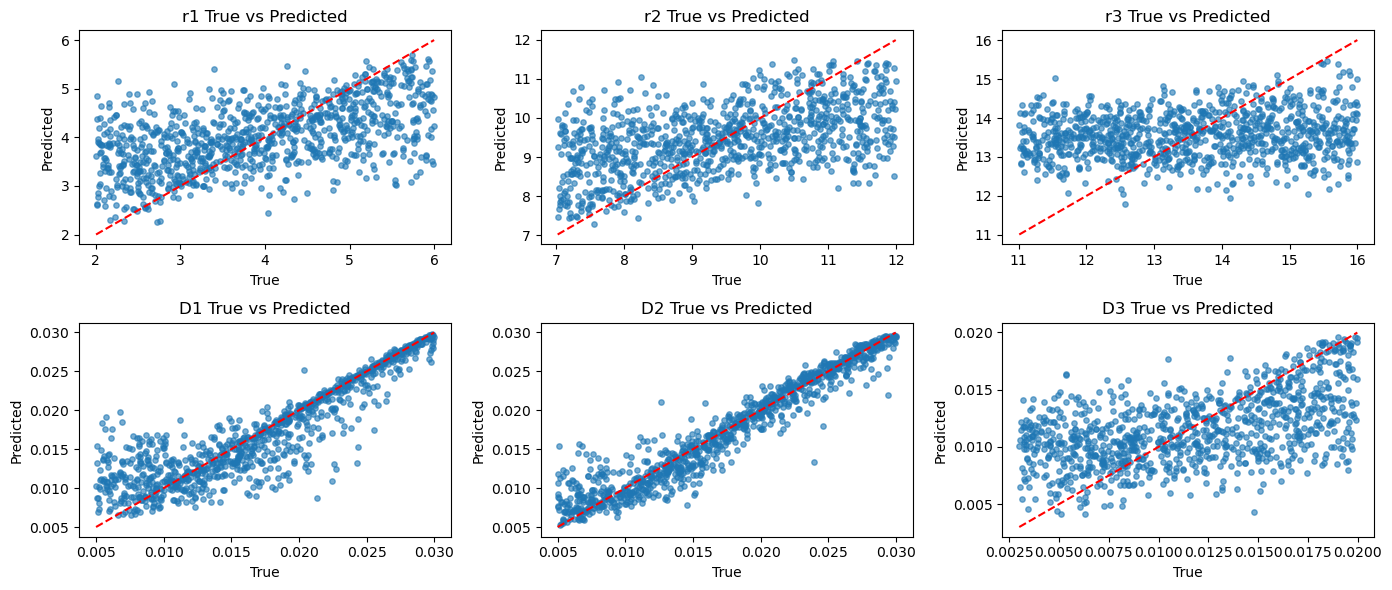

In [14]:
plt.figure(figsize=(14,6))

for i, col in enumerate(target_cols):
    plt.subplot(2, 3, i+1)
    
    actual = y_test.iloc[:, i]
    pred   = y_pred[:, i]
    
    mn = min(actual.min(), pred.min())
    mx = max(actual.max(), pred.max())
    
    plt.scatter(actual, pred, s=15, alpha=0.6)
    plt.plot([mn, mx], [mn, mx], 'r--')
    
    plt.title(f"{col} True vs Predicted")
    plt.xlabel("True")
    plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

In [15]:
np.save("true_inverse_A_RF.npy", y_test)
np.save("pred_inverse_A_RF.npy", y_pred)